In [1]:
from google.colab import files
uploaded= files.upload()

Saving sample_images_metadata.csv to sample_images_metadata.csv


In [2]:
import pandas as pd

df = pd.read_csv('sample_images_metadata.csv')
df.head()

,date,explanation,hdurl,media_type,service_version,title,url,copyright,local_filename
0,1995-06-16,Today's Picture: Explanation: If the Earth...,https://apod.nasa.gov/apod/image/e_lens.gif,image,v1,Neutron Star Earth,https://apod.nasa.gov/apod/image/e_lens.gif,NaN,1995-06-16.gif
1,1995-06-20,"Today's Picture: June 20, 1995 The Pleiades...",https://apod.nasa.gov/apod/image/pleiades2.gif,image,v1,Pleiades Star Cluster,https://apod.nasa.gov/apod/image/pleiades2.gif,NaN,1995-06-20.gif
2,1995-06-21,"Today's Picture: June 21, 1995 The Aftermat...",https://apod.nasa.gov/apod/image/sn1987a_hst.gif,image,v1,Supernova 1987a Aftermath,https://apod.nasa.gov/apod/image/sn1987a_hst.gif,NaN,1995-06-21.gif
3,1995-06-22,In 1972 Astronauts on the United States's last...,https://apod.nasa.gov/apod/image/earth_a17.gif,image,v1,Earth from Apollo 17,https://apod.nasa.gov/apod/image/earth_a17.gif,NaN,1995-06-22.gif
4,1995-06-23,"What if you could ""see"" gamma rays? This compu...",https://apod.nasa.gov/apod/image/egret_gro.gif,image,v1,Gamma Ray Sky Map,https://apod.nasa.gov/apod/image/egret_gro.gif,NaN,1995-06-23.gif


In [3]:
print(df.columns)

Index(['date', 'explanation', 'hdurl', 'media_type', 'service_version',
       'title', 'url', 'copyright', 'local_filename'],
      dtype='object')


In [4]:
import pandas as pd

df = pd.read_csv('sample_images_metadata.csv')

# keep only images
df = df[df['media_type'] == 'image']
df = df.dropna(subset=['hdurl']).reset_index(drop=True)

print(df.shape)

(100, 9)


In [5]:
import os
import requests
from tqdm import tqdm

os.makedirs('/content/images', exist_ok=True)

valid_indices = []

def download_image(url, path):
    try:
        r = requests.get(url, timeout=8)
        if r.status_code == 200:
            with open(path, 'wb') as f:
                f.write(r.content)
            return True
    except:
        return False
    return False

limit = 1500  # keep manageable

for i in tqdm(range(min(limit, len(df)))):
    url = df.iloc[i]['hdurl']
    path = f'/content/images/{i}.jpg'

    if download_image(url, path):
        valid_indices.append(i)

print("Downloaded:", len(valid_indices))

100%|██████████| 100/100 [00:24<00:00,  4.03it/s]

Downloaded: 100


In [6]:
import shutil

df_clean = df.iloc[valid_indices].reset_index(drop=True)

clean_folder = '/content/images_clean'
os.makedirs(clean_folder, exist_ok=True)

for new_idx, old_idx in enumerate(valid_indices):
    shutil.copy(f'/content/images/{old_idx}.jpg',
                f'{clean_folder}/{new_idx}.jpg')

print("Final dataset:", df_clean.shape)

Final dataset: (100, 9)


In [7]:
def label_data(title):
    title = title.lower()

    if 'galaxy' in title:
        return 0
    elif 'nebula' in title:
        return 1
    elif 'planet' in title or 'moon' in title:
        return 2
    else:
        return 3

df_clean['label'] = df_clean['title'].apply(label_data)

In [8]:
from sklearn.model_selection import train_test_split

train_df, val_df = train_test_split(df_clean, test_size=0.2, random_state=42)

In [9]:
from torch.utils.data import Dataset
from PIL import Image

class APODDataset(Dataset):
    def __init__(self, df, img_dir, transform=None):
        self.df = df
        self.img_dir = img_dir
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        img_path = f"{self.img_dir}/{idx}.jpg"
        image = Image.open(img_path).convert("RGB")
        label = self.df.iloc[idx]['label']

        if self.transform:
            image = self.transform(image)

        return image, label

In [10]:
from torchvision import transforms

transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(15),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor()
])

In [11]:
from torch.utils.data import DataLoader

train_dataset = APODDataset(train_df, clean_folder, transform)
val_dataset   = APODDataset(val_df, clean_folder, transform)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader   = DataLoader(val_dataset, batch_size=32)

In [12]:
from torchvision import models
import torch.nn as nn
import torch

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = models.efficientnet_b0(pretrained=True)

model.classifier[1] = nn.Linear(model.classifier[1].in_features, 4)

model = model.to(device)

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=EfficientNet_B0_Weights.IMAGENET1K_V1`. You can also use `weights=EfficientNet_B0_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/efficientnet_b0_rwightman-7f5810bc.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b0_rwightman-7f5810bc.pth


100%|██████████| 20.5M/20.5M [00:00<00:00, 111MB/s] 


In [13]:
for param in model.features.parameters():
    param.requires_grad = False

In [14]:
import torch.optim as optim

criterion = nn.CrossEntropyLoss()
optimizer = optim.AdamW(model.parameters(), lr=0.0003)

epochs = 10

for epoch in range(epochs):
    model.train()
    running_loss = 0

    for images, labels in train_loader:
        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)
        loss = criterion(outputs, labels)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        running_loss += loss.item()

    print(f"Epoch {epoch+1}, Loss={running_loss:.4f}")

Epoch 1, Loss=3.9816
Epoch 2, Loss=3.6677
Epoch 3, Loss=3.5413
Epoch 4, Loss=3.3427
Epoch 5, Loss=3.1133
Epoch 6, Loss=3.1202
Epoch 7, Loss=3.0733
Epoch 8, Loss=3.1341
Epoch 9, Loss=2.9565
Epoch 10, Loss=2.9624


In [15]:
model.eval()
correct = 0
total = 0

with torch.no_grad():
    for images, labels in val_loader:
        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)
        _, preds = torch.max(outputs, 1)

        total += labels.size(0)
        correct += (preds == labels).sum().item()

print("Accuracy:", 100 * correct / total)

Accuracy: 60.0


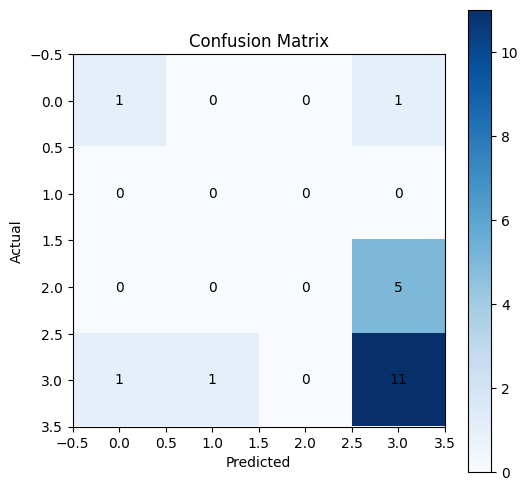

In [18]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import numpy as np

cm = confusion_matrix(labels, preds)

plt.figure(figsize=(6,6))
plt.imshow(cm, cmap='Blues')
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

for i in range(len(cm)):
    for j in range(len(cm)):
        plt.text(j, i, cm[i][j], ha='center', va='center')

plt.colorbar()
plt.show()

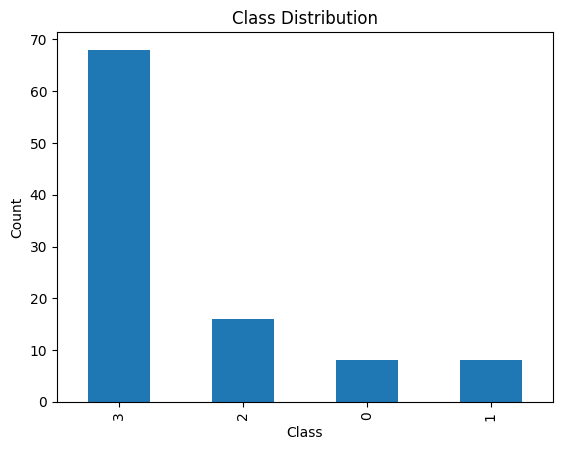

In [20]:
import matplotlib.pyplot as plt

df_clean['label'].value_counts().plot(kind='bar')
plt.title("Class Distribution")
plt.xlabel("Class")
plt.ylabel("Count")
plt.show()